# Goal of this notebook:

I want to recreate Table 1 from https://arxiv.org/pdf/2112.05176 where the times for mGST are shown.
The idea would be to show that our algorithm is faster already for 2Q and 3Q.
This means our algorithm not only allows to perform 4Q GST but also makes smaller GST's significantly cheaper.

We need to use the same parameters as the authors did for 2Q and 3Q GST to make it fair:

* Single qubit: length 7, 1000 shots per sequence, 92 sequence
* Two qubits: length 7, 1000 shots, 900-something sequences
* Three qubits: length 7, 1000 shots, 1974 sequences

In [1]:
%load_ext autoreload
%autoreload 2
from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, GSTConfiguration, get_compressed_perturbed_rep_from_mgst
from mGST.trust_region import run_riemannian_optimization
from mGST.typing import OptimizationScheduleItem, TrustRegionOptions, GradientDescentOptions, OperatorSchedule
from mGST.visualization import plot_cost_function, plot_alternating_optimization

import jax.numpy as jnp

backend = "iqmfakeapollo"

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup (parameters, configuration and initial tensors)

In [2]:
depth = 7
num_shots = 1000
num_seq_1q = 92
num_seq_2q = 900
num_se_3q = 1974

## 2Q

### Rank 1

In [3]:
kraus_rank_1 = 1

Q2_GST_rank_1 = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYICZ",
    num_circuits=num_seq_2q,
    shots=num_shots,
    rank=kraus_rank_1,
)

kraus_tensor_mgst_2q_rank_1, kraus_mgst_2q_rank_1, povm_mgst_2q, state_mgst_2q, prob_matrix_2q, indices_list_2q = get_full_mgst_parameters_from_configuration(
    Q2_GST_rank_1, backend, only_jax_variables=True
)

2026-02-24 22:04:34,455 - iqm.benchmarks.logging_config - INFO - Generating 900 random GST circuits
2026-02-24 22:04:34,973 - iqm.benchmarks.logging_config - INFO - Will transpile all 900 circuits according to fixed physical layout
2026-02-24 22:04:35,312 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-02-24 22:04:37,908 - iqm.benchmarks.logging_config - INFO - Submitting batch with 900 circuits corresponding to qubits [0, 1]
2026-02-24 22:04:37,922 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-02-24 22:04:37,981 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-02-24 22:04:38,041 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-02-24 22:04:39,219 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-02-24 22:04:41,196 - iqm.benchmarks.logging_config - INFO - Run complet

In [11]:
# Kraus is already perturbed
kraus_tensor_init_2q_rank_1 = jnp.array(kraus_tensor_mgst_2q_rank_1)

In [12]:
povm_psd_init_2q, state_psd_init_2q = get_compressed_perturbed_rep_from_mgst(povm_mgst_2q, state_mgst_2q)
cost_fn_kwargs_2q = {
    "indices_list": indices_list_2q,
    "prob_matrix": prob_matrix_2q,
    "jit": True,
}

In [13]:
init_operators_jax_2q_rank_1 = {
    "kraus_tensor_init": kraus_tensor_init_2q_rank_1,
    "povm_psd_init": povm_psd_init_2q,
    "state_psd_init": state_psd_init_2q,
}

initial_cost_value = cost_function_jax_mps(kraus_tensor_init_2q_rank_1, povm_psd_init_2q, state_psd_init_2q, **cost_fn_kwargs_2q)
print("Initial cost value:", initial_cost_value)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/low_level_jit.py:640: UserWarning: Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.
  warnings.warn("Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.")


at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 43 the new count changed to: 4
at iteration 110 the new count changed to: 5
at iteration 178 the new count changed to: 6
at iteration 246 the new count changed to: 7
at iteration 314 the new count changed to: 8
at iteration 382 the new count changed to: 9
at iteration 450 the new count changed to: 10
at iteration 525 the new count changed to: 11
at iteration 600 the new count changed to: 12
at iteration 675 the new count changed to: 13
at iteration 750 the new count changed to: 14
at iteration 825 the new count changed to: 15
Initial cost value: 0.005212969035191423


# Optimization

In [ ]:
num_iterations_outer = 5
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-6
kappa = 1/10
theta = 0.5 # should have been 1!

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=0.5))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=10, theta_cg=0.5, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=10, theta_cg=0.5, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=10, theta_cg=0.5, kappa_cg=0.1, verbose_cg=True))])}

## 2Q

In [25]:
optimized_operators_2q_rank_1, cost_fn_history_2q_rank_1 = run_riemannian_optimization(
    **init_operators_jax_2q_rank_1,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs_2q,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True, # to be able to plot cost function history for each operator optimization step
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.212969e-03. |r∇f(x)|: 6.809384e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 4.712858e-03. |r∇f(x)|: 3.354995e-03. Radius: 2.00e-01
TCG finished after: 3/10 iters. 
 Reason: Stopping criteria met 🛑. |r_k| = 4.90e-05
---------------------------------------
TR Iteration: 2. f(x): 4.518629e-03. |r∇f(x)|: 7.116171e-05. Radius: 2.00e-01
TCG finished after: 4/10 iters. 
 Reason: Stopping criteria met 🛑. |r_k| = 1.40e-07
---------------------------------------
TR Iteration: 3. f(x): 4.518547e-03. |r∇f(x)|: 1.407654e-07. Radius: 2.00e-01
TCG finished after: 2/10 iters. 
 Reason: Negative curvature encountered 📉.
-------------

# Plotting

In [16]:
num_qubits_2 = 2
dim_2q = 2 ** num_qubits_2
state_rank_2q = dim_2q
povm_rank_2q = dim_2q

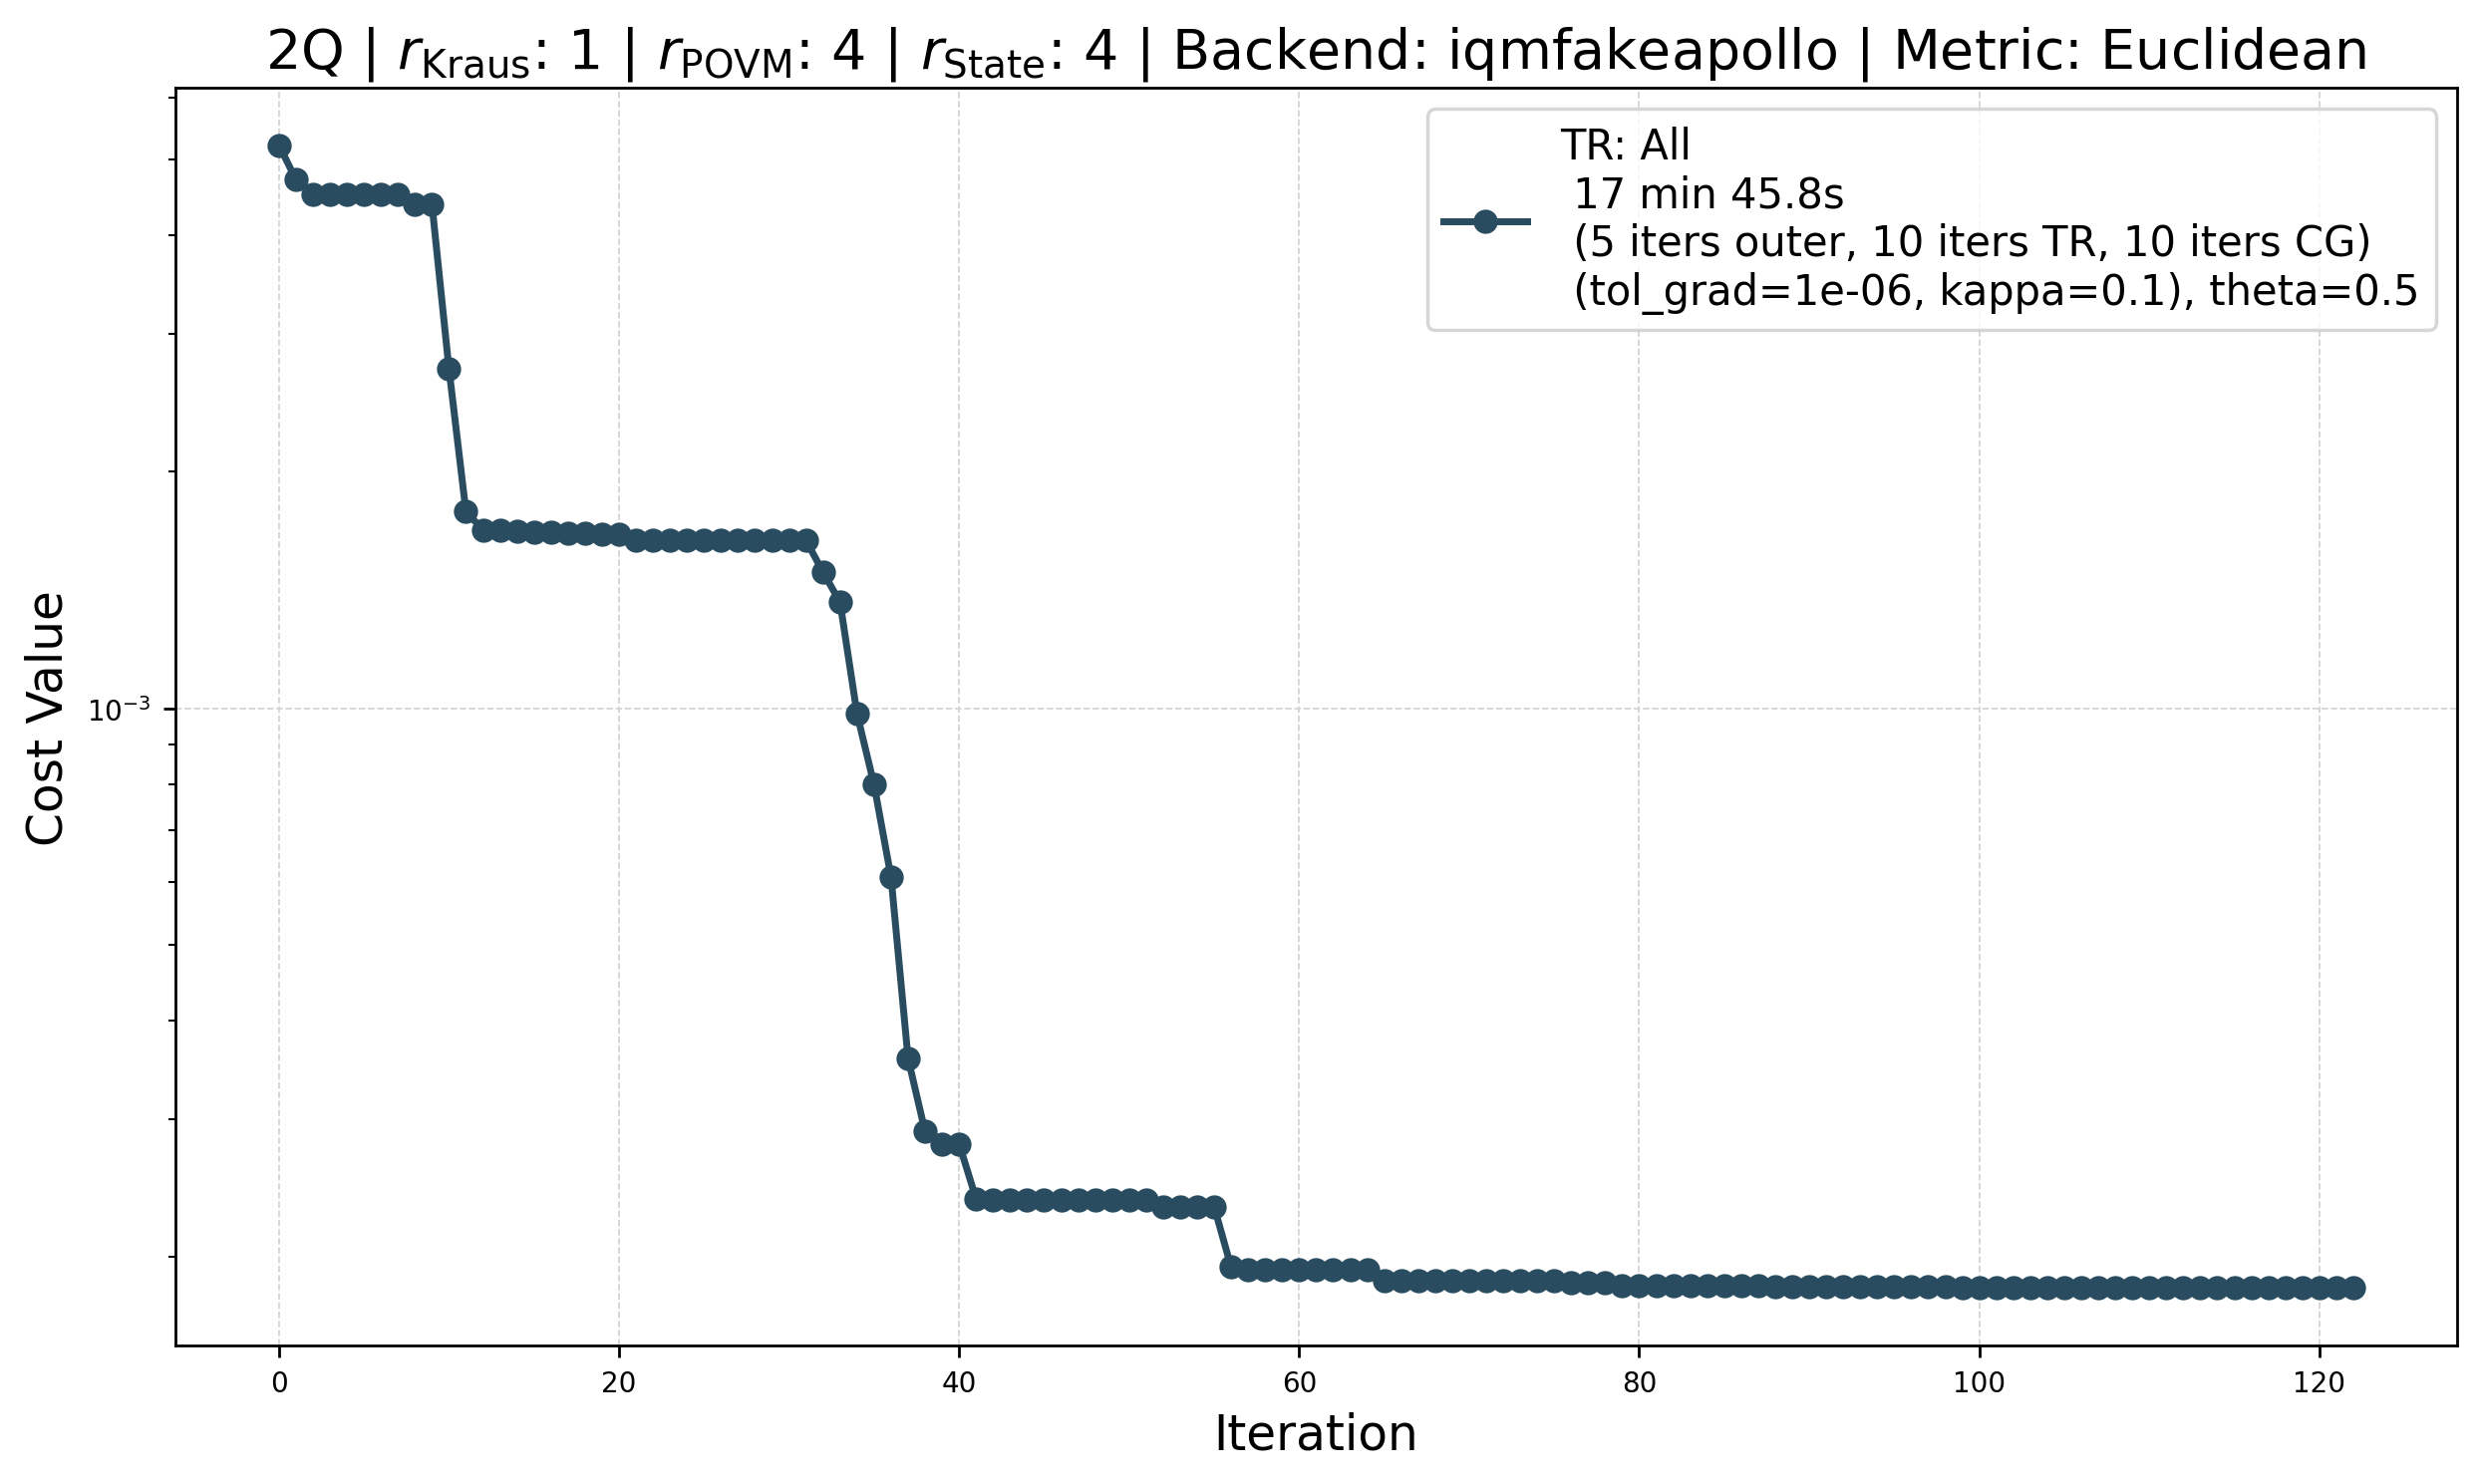

In [31]:
cost_fn_lists = [
    cost_fn_history_2q_rank_1,
]

labels = [
    f"TR: All \n 17 min 45.8s \n ({num_iterations_outer} iters outer, {num_iterations_tr} iters TR, {num_iterations_cg} iters CG) \n (tol_grad={tol_grad}, kappa={kappa}), theta={0.5}",
]

title = rf"{num_qubits_2}Q | $r_\mathrm{{Kraus}}$: {kraus_rank_1} | $r_\mathrm{{POVM}}$: {povm_rank_2q} | $r_\mathrm{{State}}$: {state_rank_2q} | Backend: {backend} | Metric: Euclidean"

plot_cost_function(cost_fn_lists, title=title, labels=labels)

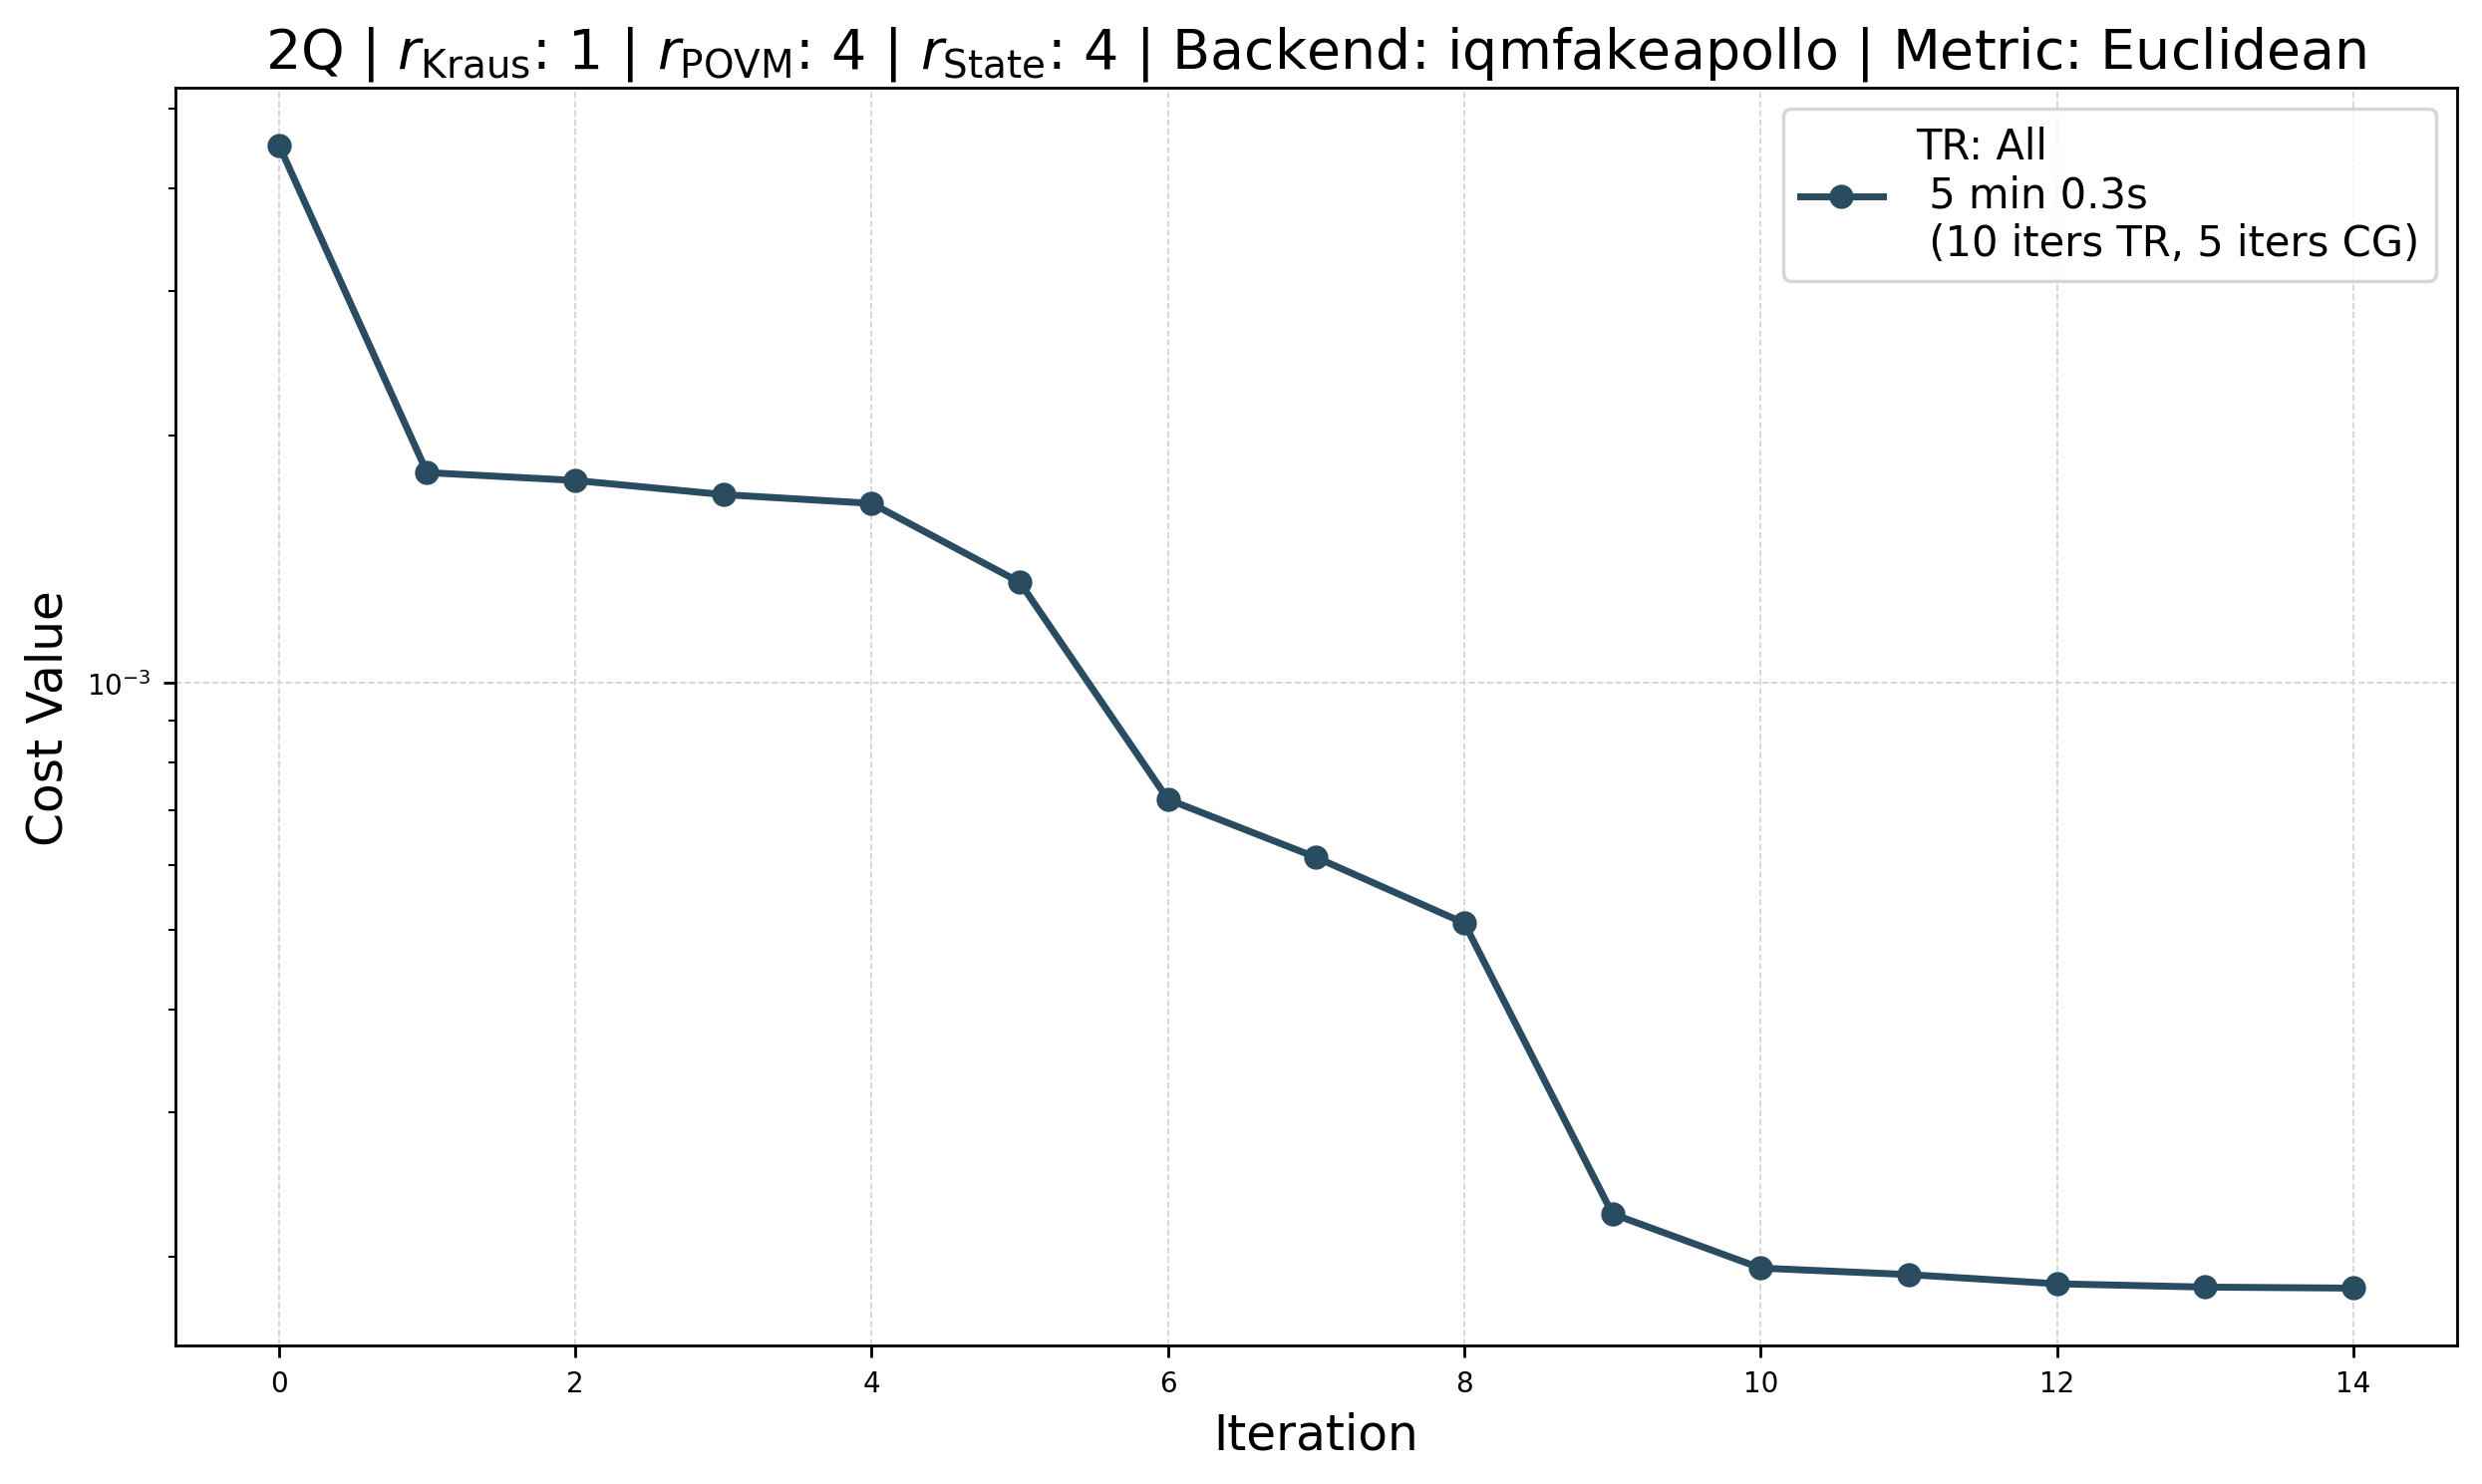

In [ ]:
cost_fn_lists = [
    cost_fn_history_2q_rank_1,
]

labels = [
    "TR: All \n 15 min 0.3s \n (10 iters TR, 5 iters CG)",
]

title = rf"{num_qubits_2}Q | $r_\mathrm{{Kraus}}$: {kraus_rank_1} | $r_\mathrm{{POVM}}$: {povm_rank_2q} | $r_\mathrm{{State}}$: {state_rank_2q} | Backend: {backend} | Metric: Euclidean"

plot_cost_function(cost_fn_lists, title=title, labels=labels)

In [ ]:
# Idea for 4Q: re-use the value of the riemannian hessian-vector product so it's not needed again in the quality quotient
# (decrease prefactor by half)